In [3]:
import io
import zipfile
import pandas as pd
import requests

zip_url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/Week%204%20-%20Data%20Understanding/W4D4%20-%20Data%20Preprocessing%20%26%20T/titanic%20dataset.zip"
response = requests.get(zip_url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    df = pd.read_csv(z.open("titanic dataset/train.csv"))

print(f"Lignes initiales : {df.shape[0]}")
print(f"Doublons : {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Lignes après suppression : {df.shape[0]}")

Lignes initiales : 891
Doublons : 0
Lignes après suppression : 891


In [4]:
#EXERCISE2

from sklearn.impute import SimpleImputer

print(df.isnull().sum())

df_dropna = df.dropna(subset=["Embarked"])

imputer_median = SimpleImputer(strategy="median")
df["Age"] = imputer_median.fit_transform(df[["Age"]])

df["Cabin"] = df["Cabin"].fillna("Inconnu")

print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64


In [5]:
#EXERCISE3

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


def encode_title(title):
    if title in ["Mr", "Miss", "Mrs", "Master"]:
        return title
    else:
        return "Rare"


df["Title"] = df["Title"].apply(encode_title)

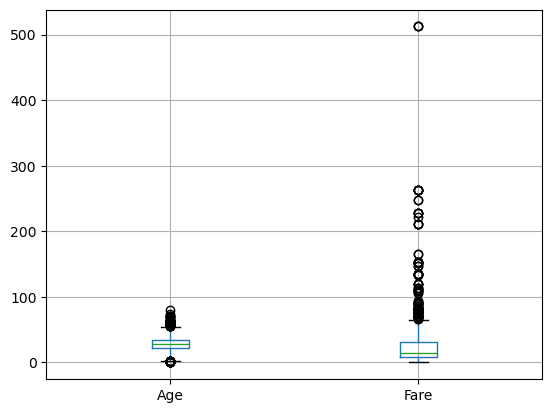

In [6]:
#EXERCISE4

import matplotlib.pyplot as plt
import numpy as np

df[["Age", "Fare"]].boxplot()
plt.show()

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

seuil_98 = df["Fare"].quantile(0.98)
df["Fare_capped"] = np.where(df["Fare"] > seuil_98, seuil_98, df["Fare"])

df["Fare_log"] = np.log1p(df["Fare"])



In [7]:
#EXERCISE5

from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler_std = StandardScaler()
df["Age_scaled"] = scaler_std.fit_transform(df[["Age"]])

scaler_minmax = MinMaxScaler()
df["Fare_scaled"] = scaler_minmax.fit_transform(df[["Fare_capped"]])

In [8]:
#EXERCISE6

df_encoded = pd.get_dummies(
    df, columns=["Sex", "Embarked", "Title"], drop_first=True
)


In [9]:
#EXERCISE7

bacs = [0, 12, 18, 60, 100]
etiquettes = ["Enfant", "Adolescent", "Adulte", "Senior"]
df_encoded["AgeGroup"] = pd.cut(
    df_encoded["Age"], bins=bacs, labels=etiquettes
)

df_final = pd.get_dummies(df_encoded, columns=["AgeGroup"], drop_first=True)